In [1]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [34]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

    country  year  incidence  mortality           gdp       bmi    pop_65  \
0      chad  1990  11.784239  15.747424   1705.042265  0.038681  3.455495   
1     india  1990   8.650421   8.913174   2203.147039  0.014403  4.037870   
2      oman  1990   5.197615   6.765138  35201.552487  0.052449  2.453040   
3    zambia  1990  14.798816  20.414687   2425.111287  0.110025  2.880287   
4  djibouti  1990  15.847623  16.948879           NaN  0.061933  2.993589   

   urban_pop  life_exp  fertility  labor_rate  internet  broadband  \
0     20.811    48.799      7.219      64.570       0.0        NaN   
1     25.547    59.358      4.045      30.225       0.0        NaN   
2     66.102    71.752      6.456      22.489       0.0        NaN   
3     39.407    49.410      6.567      51.414       0.0        NaN   
4     75.957    57.445      5.931      16.026       0.0        NaN   

   health_exp  smoking  
0         NaN      3.3  
1         NaN     40.8  
2         NaN      0.6  
3         NaN   

In [35]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

173


In [36]:
initial_years=final_df['year'].nunique()
print(initial_years)

34


# OECD  Countries :

In [37]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czech', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Creat Dummy Variables:

In [39]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    4681
1    1122
Name: count, dtype: int64


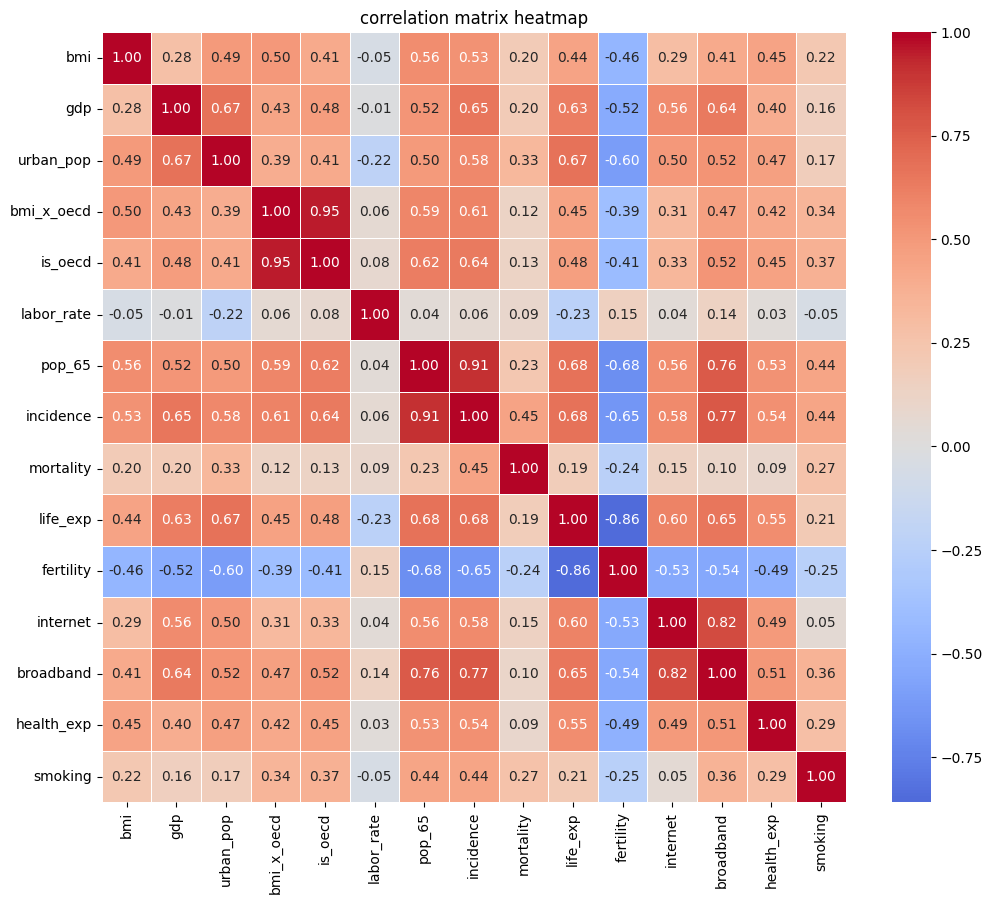

In [40]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'life_exp', 'fertility','internet','broadband','health_exp','smoking']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [41]:
final_df['is_oecd']= final_df['country'].str.lower().str.strip().isin(oecd_countries).astype(int)
print(final_df['is_oecd'].value_counts())

is_oecd
0    4681
1    1122
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [42]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    4044
1    1759
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [43]:
final_df['dm_high_life_exp']=(final_df['life_exp']> 75).astype(int)
print(final_df['dm_high_life_exp'].value_counts())

dm_high_life_exp
0    3172
1    2631
Name: count, dtype: int64


In [44]:
comparison_inc= final_df.groupby('dm_high_life_exp').incidence.mean()
print(comparison_inc)

dm_high_life_exp
0    23.191882
1    89.885028
Name: incidence, dtype: float64


In [45]:
comparison_incid= final_df.groupby('dm_high_life_exp').incidence.mean()
print(comparison_incid)

dm_high_life_exp
0    23.191882
1    89.885028
Name: incidence, dtype: float64


In [46]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].head(100))

    year                   country  is_oecd  dm_high_aging_society  \
0   1990                      chad        0                      0   
1   1990                     india        0                      0   
2   1990                      oman        0                      0   
3   1990                    zambia        0                      0   
4   1990                  djibouti        0                      0   
..   ...                       ...      ...                    ...   
95  1990                   andorra        0                      0   
96  1990                 nicaragua        0                      0   
97  1990                 indonesia        0                      0   
98  1990                uzbekistan        0                      0   
99  1990  northern mariana islands        0                      0   

    dm_high_life_exp  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
..               ... 

# interaction of is_oecd variable and gdp

In [47]:
final_df['log_gdp']= np.log(final_df['gdp'])
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    NaN
Name: log_gdp_is_oecd, dtype: float64


In [48]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp'] = np.log(final_df['gdp'])
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [16]:
print(final_df[['country','gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society', 'dm_high_life_exp']].sample(20).round(2))

                country        gdp  is_oecd  log_gdp_is_oecd  \
3514              benin    3588.33        0             0.00   
3438           kiribati    3020.49        0             0.00   
386         timor-leste    3482.65        0             0.00   
69             cameroon    3822.94        0             0.00   
1681             france   49130.42        1            10.80   
2784              malta   53371.02        0             0.00   
1786            finland   55053.39        1            10.92   
3133          australia   55288.12        1            10.92   
839    marshall islands    4075.16        0             0.00   
2048          guatemala   10297.84        0             0.00   
565               malta   32034.09        0             0.00   
1075              qatar  109579.79        0             0.00   
3908          singapore  120114.13        0             0.00   
545          madagascar    1701.44        0             0.00   
662                chad    1871.64      

In [49]:
start_year=final_df['year'].min()
end_year=final_df['year'].max()
print(final_df[['year', 'country', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
print(f"number of countries with high life_expectency in {start_count}")
print(f"number of countries with high life_expectency in {end_count}")

      year                   country  dm_high_aging_society  dm_high_life_exp
5703  2021                  zimbabwe                      0                 0
5704  2021  central african republic                      0                 0
5705  2021                   bahrain                      0                 1
5706  2021                madagascar                      0                 0
5707  2021                    malawi                      0                 0
...    ...                       ...                    ...               ...
5798  2023                    monaco                      1                 1
5799  2023                  dominica                      1                 0
5800  2023                 argentina                      1                 1
5801  2023        dominican republic                      0                 1
5802  2023                     nauru                      0                 0

[100 rows x 4 columns]
number of countries with high life_expec

# delet percentage of rows with missing value(NA):

In [67]:
# report of missing values
missing_report = (final_df.isnull().sum() / len(final_df)) * 100
print(missing_report[missing_report > 0])

gdp            3.653283
labor_rate     8.064794
internet      13.337929
broadband     40.496295
health_exp    34.103050
smoking       15.043943
log_gdp        3.653283
dtype: float64


In [51]:
clean_df= final_df.dropna(subset=['incidence','mortality', 'gdp', 'pop_65', 'urban_pop', 'life_exp', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet', 'broadband', 'health_exp', 'smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                  0
year                     0
incidence                0
mortality                0
gdp                      0
bmi                      0
pop_65                   0
urban_pop                0
life_exp                 0
fertility                0
labor_rate               0
internet                 0
broadband                0
health_exp               0
smoking                  0
is_oecd                  0
bmi_x_oecd               0
dm_high_aging_society    0
dm_high_life_exp         0
log_gdp                  0
log_gdp_is_oecd          0
dtype: int64


# Building stepwise regression

# Step 1: Adding Urban Population and log_gdp

In [52]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['incidence'],exog_1_fe, entity_effects=True, time_effects=True).fit()
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0108
Estimator:                   PanelOLS   R-squared (Between):              0.1839
No. Observations:                2678   R-squared (Within):               0.1271
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1768
Time:                        15:16:12   Log-likelihood                   -8496.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      13.734
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(2,2516)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             13.734
                            

# Step 2: Adding Pop_65:

In [53]:
exog_2_fe = df_step[['log_gdp', 'urban_pop', 'pop_65']]
model_2_fe = PanelOLS(df_step['incidence'], exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0370
Estimator:                   PanelOLS   R-squared (Between):              0.7169
No. Observations:                2678   R-squared (Within):               0.2932
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.7112
Time:                        15:16:19   Log-likelihood                   -8460.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      32.247
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(3,2515)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             32.247
                            

# Step 3: Adding Labor Rate:

In [54]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_3_fe=PanelOLS(df_step['incidence'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0371
Estimator:                   PanelOLS   R-squared (Between):              0.4102
No. Observations:                2678   R-squared (Within):               0.2910
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.3990
Time:                        15:16:23   Log-likelihood                   -8460.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      24.238
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(4,2514)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             24.238
                            

# Step 4: Adding BMI:

In [55]:
exog_4_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_4_fe=PanelOLS(df_step['incidence'], exog_4_fe, entity_effects=True, time_effects= True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0670
Estimator:                   PanelOLS   R-squared (Between):              0.4555
No. Observations:                2678   R-squared (Within):               0.2689
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.4400
Time:                        15:16:26   Log-likelihood                   -8417.9
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      36.109
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(5,2513)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             36.109
                            

# Step 5: Adding is_oecd as Dummy Variable:

In [56]:
exog_5_fe=sm.add_constant(df_step[['log_gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd']])
model_5_fe=PanelOLS(df_step['incidence'], exog_5_fe, entity_effects=True, time_effects=True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0697
Estimator:                   PanelOLS   R-squared (Between):             -0.2998
No. Observations:                2678   R-squared (Within):               0.2660
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.3202
Time:                        15:16:32   Log-likelihood                   -8414.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      31.368
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(6,2512)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             31.368
                            

# Step 6: Adding High aging society as Dummy Variable:

In [57]:
exog_6_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society']])
model_6_fe = PanelOLS(df_step['incidence'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0725
Estimator:                   PanelOLS   R-squared (Between):             -0.2878
No. Observations:                2678   R-squared (Within):               0.2744
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.3087
Time:                        15:16:36   Log-likelihood                   -8410.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      28.053
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(7,2511)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             28.053
                            

# Step 7: Adding High life exp as Dummy Variable:

In [58]:
exog_7_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp']])
model_7_fe = PanelOLS(df_step['incidence'], exog_7_fe, entity_effects=True, time_effects= True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0740
Estimator:                   PanelOLS   R-squared (Between):             -0.1927
No. Observations:                2678   R-squared (Within):               0.2816
Date:                Mon, Mar 09 2026   R-squared (Overall):             -0.2137
Time:                        15:16:41   Log-likelihood                   -8407.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      25.071
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(8,2510)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             25.071
                            

# create labor_rate * is_oecd variable:

In [59]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Step 8: Adding labor_rate * is_oecd:

In [28]:
exog_8_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi',
                                     'log_gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd']])
model_8_fe = PanelOLS(df_step['incidence'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.0878
Estimator:                   PanelOLS   R-squared (Between):              0.1233
No. Observations:                2678   R-squared (Within):               0.2550
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1062
Time:                        15:11:04   Log-likelihood                   -8387.7
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      26.832
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                  F(9,2509)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             26.832
                            

# Step 9: Adding internet:

In [60]:
exog_9_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet']])
model_9_fe = PanelOLS(df_step['incidence'], exog_9_fe, entity_effects=True, time_effects= True).fit()
print(model_9_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1457
Estimator:                   PanelOLS   R-squared (Between):              0.2082
No. Observations:                2678   R-squared (Within):               0.5239
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.1940
Time:                        15:16:53   Log-likelihood                   -8300.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      42.768
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(10,2508)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             42.768
                            

# Step  10: Adding broadband:

In [61]:
exog_10_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband']])
model_10_fe = PanelOLS(df_step['incidence'], exog_10_fe, entity_effects=True, time_effects= True).fit()
print(model_10_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1668
Estimator:                   PanelOLS   R-squared (Between):              0.3241
No. Observations:                2678   R-squared (Within):               0.5220
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.3130
Time:                        15:16:57   Log-likelihood                   -8266.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      45.637
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(11,2507)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             45.637
                            

# Step  11: Adding smoking:

In [62]:
exog_11_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd',
                                     'dm_high_aging_society','dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking']])
model_11_fe = PanelOLS(df_step['incidence'], exog_11_fe, entity_effects=True, time_effects= True).fit()
print(model_11_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.1992
Estimator:                   PanelOLS   R-squared (Between):              0.6339
No. Observations:                2678   R-squared (Within):               0.4371
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.6209
Time:                        15:17:05   Log-likelihood                   -8213.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      51.947
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(12,2506)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             51.947
                            

# step 12: adding health_exp:

In [63]:
exog_12_fe = sm.add_constant(df_step[['log_gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','log_gdp_is_oecd','dm_high_aging_society',
                                      'dm_high_life_exp', 'labor_rate * is_oecd','internet', 'broadband','smoking','health_exp']])
model_12_fe = PanelOLS(df_step['incidence'], exog_12_fe, entity_effects=True, time_effects= True).fit()
print(model_12_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              incidence   R-squared:                        0.2033
Estimator:                   PanelOLS   R-squared (Between):              0.6409
No. Observations:                2678   R-squared (Within):               0.4345
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.6276
Time:                        15:17:12   Log-likelihood                   -8206.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      49.163
Entities:                         137   P-value                           0.0000
Avg Obs:                       19.547   Distribution:                 F(13,2505)
Min Obs:                       3.0000                                           
Max Obs:                       24.000   F-statistic (robust):             49.163
                            

# Comparing results of all Fixed Effect models:

In [64]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    'FE model 9': model_9_fe,
    'FE model 10': model_10_fe,
    'FE model 11': model_11_fe,
    'FE model 12': model_12_fe })

print(Compare_results_fixed_Effect)

                                                                                               Model Comparison                                                                                              
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8     FE model 9    FE model 10    FE model 11    FE model 12
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence      incidence
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS 